# Machine Translation (English to Vietnamese) under Noisy Conditions

In this notebook, you will learn how to:
1. Preprocess and handle parallel text corpora.
2. Build a baseline Sequence-to-Sequence model using standard Recurrent Neural Networks (RNN).
3. Evaluate translation quality using the BLEU metric.
4. Develop strategies to make your model robust against noisy data within a strict parameter budget.

---

## Problem description
Machine Translation is a sequence-to-sequence problem mapping a source language to a target language. 
Unlike classification, the output sequence length is dynamic and may differ from the input length. 
We use special tokens to guide the generation:
* `<pad>`: Padding token to make batch sentences equal in length.
* `<unk>`: Unknown word token.
* `<sos>`: Start of sentence token.
* `<eos>`: End of sentence token.

However, real-world data is rarely clean. In this lab, the noise have been injected into the training dataset. The noise includes missing spaces, garbage words, and inverted grammar. Your ultimate goal in the Lab Exercise is to overcome these noise anomalies and output clean Vietnamese translations.

![](framework.png)

# 1. Imports and global settings

In [ ]:
import os
import random
import time
import math
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from nltk.translate.bleu_score import corpus_bleu

In [ ]:
# Reproducibility seed
# Using a fixed seed helps make results more repeatable
SEED = 42

def fix_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

fix_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Setup complete. Using device: {device}")

Setup complete. Using device: cuda


# 2. Data preparation

We load parallel text files where each line contains a pair of sentences.
The English sentences contain noise, while the Vietnamese sentences are clean.

We will:
1. Clean text (lowercase, retain alphanumeric characters and basic punctuation).
2. Build vocabulary mappings from words to unique integer indices.
3. Convert text sentences into integer sequences with `<sos>` and `<eos>` tokens.
4. Pad sequences to uniform lengths.

In [ ]:
class Vocabulary:
    def __init__(self):
        self.word2index = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
        self.index2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
        self.num_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2index:
                self.word2index[word] = self.num_words
                self.index2word[self.num_words] = word
                self.num_words += 1

def normalize_string(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z0-9.!?áàảãạâấầẩẫậăắằẳẵặéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ\s]+", r"", s)
    s = re.sub(r"\s+", r" ", s)
    return s.strip()

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, max_len=50):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, trg_sentence = self.pairs[idx]
        src_tokens = [self.src_vocab.word2index.get(w, 1) for w in src_sentence.split()][:self.max_len - 2]
        trg_tokens = [self.trg_vocab.word2index.get(w, 1) for w in trg_sentence.split()][:self.max_len - 2]
        
        src_indices = [2] + src_tokens + [3]
        trg_indices = [2] + trg_tokens + [3]
        return src_indices, trg_indices

def collate_fn(batch):
    src_list, trg_list = [], []
    for src, trg in batch:
        src_list.append(torch.tensor(src))
        trg_list.append(torch.tensor(trg))
    src_padded = nn.utils.rnn.pad_sequence(src_list, batch_first=True, padding_value=0)
    trg_padded = nn.utils.rnn.pad_sequence(trg_list, batch_first=True, padding_value=0)
    return src_padded, trg_padded

def read_langs(src_path, trg_path, max_samples=None):
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = f.readlines()
    with open(trg_path, "r", encoding="utf-8") as f:
        trg_lines = f.readlines()
    
    pairs = []
    for s, t in zip(src_lines, trg_lines):
        s_norm = normalize_string(s)
        t_norm = normalize_string(t)
        if s_norm and t_norm:
            pairs.append((s_norm, t_norm))
            
    if max_samples:
        pairs = pairs[:max_samples]
    return pairs

In [ ]:
# File paths for train, validation, and test splits
train_src = "./en-vi-translation-data/train_noisy.en.txt"
train_trg = "./en-vi-translation-data/train.vi.txt"
val_src = "./en-vi-translation-data/val_noisy.en.txt"
val_trg = "./en-vi-translation-data/val.vi.txt"
test_src = "./en-vi-translation-data/test_noisy.en.txt"
test_trg = "./en-vi-translation-data/test.vi.txt"

if os.path.exists(train_src):
    # Load dataset pairs (for faster training of baseline, we can limit samples to 30000)
    print("Loading data...")
    train_pairs = read_langs(train_src, train_trg, max_samples=30000)
    val_pairs = read_langs(val_src, val_trg)
    test_pairs = read_langs(test_src, test_trg)
    
    # Build vocabulary on training split
    src_vocab = Vocabulary()
    trg_vocab = Vocabulary()
    for s, t in train_pairs:
        src_vocab.add_sentence(s)
        trg_vocab.add_sentence(t)
        
    print(f"Source Vocabulary Size: {src_vocab.num_words}")
    print(f"Target Vocabulary Size: {trg_vocab.num_words}")
    
    MAX_LENGTH = 50
    train_dataset = TranslationDataset(train_pairs, src_vocab, trg_vocab, MAX_LENGTH)
    val_dataset = TranslationDataset(val_pairs, src_vocab, trg_vocab, MAX_LENGTH)
    test_dataset = TranslationDataset(test_pairs, src_vocab, trg_vocab, MAX_LENGTH)
    
    print(f"Dataset splits - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
else:
    print("Dataset files not found. Please run the noise injection script first.")

Loading data...


Source Vocabulary Size: 64715
Target Vocabulary Size: 9111
Dataset splits - Train: 30000, Val: 1553, Test: 1268


# 3. Data visualization

Let's print out some samples from our dataset to check the format and look at the dataset properties.

--- DATA SAMPLES INSPECTION ---
Sample 1:
  [Source]: the greatproblem for reform or transformationis the tyranny of common sense things that peoplethink quotwell it can apostbe done any other way becausethat aposs the way itaposs done . quot
  [Target]: vấn đề lớn nhất của việc cải cách hay biến đổi là phá bỏ những lề thói thông thường những thứ mà người ta nghĩ rằng . . quot nó là vậy đó làm sao làm khác đi được quot

Sample 2:
  [Source]: myself why ? and iasked
  [Target]: rồi tôi tự hỏi bản thân mình tại sao ?

Sample 3:
  [Source]: larger than someof theother symphonyhalls .it aposs
  [Target]: nó lớn hơn một vài hội trường nhạc giao hưởng .

Sample 4:
  [Source]: they were eatingthe same kinds of foods .
  [Target]: chúng ăn cùng loại thức ăn

Sample 5:
  [Source]: venerable . lmfao itwas
  [Target]: sách thật thiêng liêng .



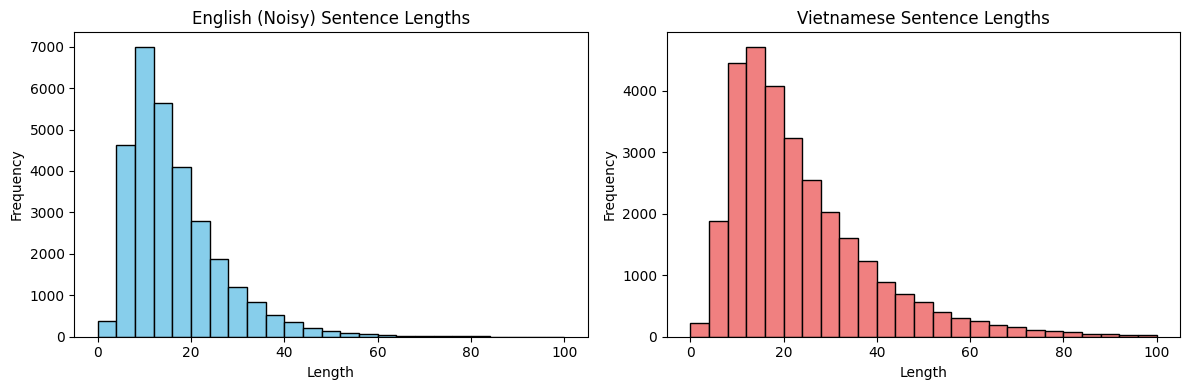

In [ ]:
# Print 5 random sentence pairs from training set to inspect
print("--- DATA SAMPLES INSPECTION ---")
for i in range(5):
    idx = random.randint(0, len(train_pairs) - 1)
    src_s, trg_s = train_pairs[idx]
    print(f'Sample {i+1}:')
    print(f'  [Source]: {src_s}')
    print(f'  [Target]: {trg_s}')
    print()

# Draw sentence length distribution
src_lengths = [len(s.split()) for s, _ in train_pairs]
trg_lengths = [len(t.split()) for _, t in train_pairs]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(src_lengths, bins=25, range=(0, 100), color='skyblue', edgecolor='black')
plt.title('English (Noisy) Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(trg_lengths, bins=25, range=(0, 100), color='lightcoral', edgecolor='black')
plt.title('Vietnamese Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4. Build the baseline Seq2Seq model

We build a baseline Seq2Seq model using standard vanilla Recurrent Neural Networks (RNN):
1. **Encoder**: Maps source words to representation vectors and runs an RNN to compute the sequence context vector (the final hidden state).
2. **Decoder**: A standard RNN initialized with the encoder's context vector, decoding target words token-by-token.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_size, batch_first=True)
        
    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_size):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, output_dim)
        
    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim
        
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        _, hidden = self.encoder(src)
        
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1
            
        return outputs

In [ ]:
# Instantiate the baseline model
EMB_DIM = 256
HIDDEN_SIZE = 512

enc = Encoder(src_vocab.num_words, EMB_DIM, HIDDEN_SIZE)
dec = Decoder(trg_vocab.num_words, EMB_DIM, HIDDEN_SIZE)
model = Seq2Seq(enc, dec, device).to(device)

In [ ]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0) # Index 0 is <pad>
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Count trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The baseline model has {count_parameters(model):,} trainable parameters.")
print("\nModel Architecture details:")
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"  {name}: {type(module).__name__} ({params:,} parameters)")

The baseline model has 24,361,879 trainable parameters.

Model Architecture details:
  encoder: Encoder (16,961,280 parameters)
  decoder: Decoder (7,400,599 parameters)


# 5. Train the model

During training, we monitor the cross-entropy loss on both the training set and validation set.
We also apply **Teacher Forcing** with a probability of 0.5 to speed up convergence during the initial epochs.

In [ ]:
BATCH_SIZE = 64
EPOCHS = 20
TEACHER_FORCING_RATIO = 0.5

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Training loop
train_losses = []
val_losses = []

print("Starting baseline model training...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for i, (src, trg) in enumerate(train_loader):
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        output = model(src, trg, TEACHER_FORCING_RATIO)
        
        # trg: [batch_size, trg_len]
        # output: [batch_size, trg_len, trg_vocab_size]
        output_dim = output.shape[-1]
        
        # Reshape for loss calculation
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, 0) # Turn off teacher forcing
            
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Starting baseline model training...


Epoch 01 | Train Loss: 5.9377 | Val Loss: 6.3280
Epoch 02 | Train Loss: 5.5220 | Val Loss: 6.3216
Epoch 03 | Train Loss: 5.3879 | Val Loss: 6.3906
Epoch 04 | Train Loss: 5.3218 | Val Loss: 6.4976
Epoch 05 | Train Loss: 5.2488 | Val Loss: 6.4209
Epoch 06 | Train Loss: 5.2417 | Val Loss: 6.4364
Epoch 07 | Train Loss: 5.1905 | Val Loss: 6.4722
Epoch 08 | Train Loss: 5.1622 | Val Loss: 6.6435
Epoch 09 | Train Loss: 5.1204 | Val Loss: 6.4860
Epoch 10 | Train Loss: 5.0928 | Val Loss: 6.4513
Epoch 11 | Train Loss: 5.0896 | Val Loss: 6.4868
Epoch 12 | Train Loss: 5.0863 | Val Loss: 6.4709
Epoch 13 | Train Loss: 5.0645 | Val Loss: 6.4812
Epoch 14 | Train Loss: 5.0491 | Val Loss: 6.4662
Epoch 15 | Train Loss: 5.0356 | Val Loss: 6.5567
Epoch 16 | Train Loss: 5.0345 | Val Loss: 6.5328
Epoch 17 | Train Loss: 5.0076 | Val Loss: 6.5721
Epoch 18 | Train Loss: 5.0032 | Val Loss: 6.4573
Epoch 19 | Train Loss: 4.9854 | Val Loss: 6.6570
Epoch 20 | Train Loss: 4.9880 | Val Loss: 6.5600


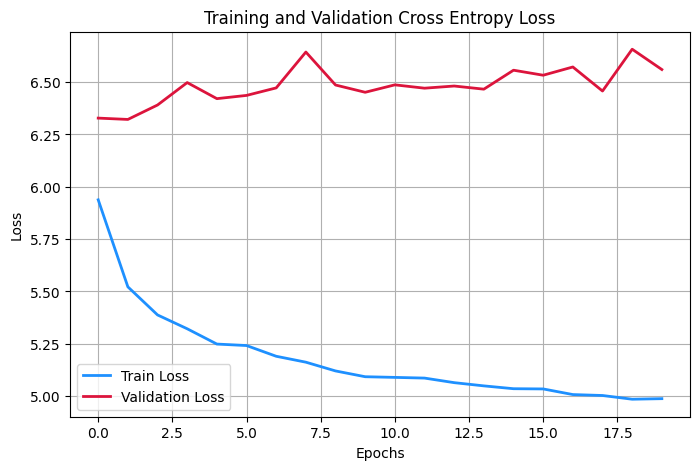

In [ ]:
# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color="dodgerblue", lw=2)
plt.plot(val_losses, label="Validation Loss", color="crimson", lw=2)
plt.title("Training and Validation Cross Entropy Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 6. Evaluate the model

To evaluate the model, we first need to generate translations. We can translate source sentences using **greedy decoding**: generating one word at a time, choosing the word with the highest probability at each step.

After that, we need a metric to evaluate translation quality. In this task, standard token-level classification accuracy is misleading because there are many valid ways to translate a single source sentence. Instead, we use the **BLEU (Bilingual Evaluation Understudy)** score, which measures the n-gram overlap between the generated translation (candidate) and the reference translations. It also applies a **brevity penalty** if the candidate translation is too short compared to the reference.


In [ ]:
def translate_sentence(model, sentence, src_vocab, trg_vocab, device, max_len=50):
    """
    Decodes the source sentence using Greedy Search.
    """
    model.eval()
    tokens = sentence.split()
    tokens = [src_vocab.word2index.get(token, 1) for token in tokens]
    tokens = [2] + tokens + [3] # Add <sos> and <eos>
    
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)
    
    with torch.no_grad():
        _, hidden = model.encoder(src_tensor)
        
    trg_tokens = [2] # <sos>
    
    for _ in range(max_len):
        trg_tensor = torch.LongTensor([trg_tokens[-1]]).to(device)
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            
        best_token = output.argmax(1).item()
        trg_tokens.append(best_token)
        
        if best_token == 3: # <eos>
            break
            
    translated_words = [trg_vocab.index2word.get(idx, "<unk>") for idx in trg_tokens]
    return translated_words[1:]
    

def calculate_bleu(model, dataset, src_vocab, trg_vocab, device, max_samples=100):
    """
    Computes corpus-level BLEU-4 score.
    """
    targets = []
    predictions = []
    
    num_samples = min(len(dataset), max_samples)
    for i in range(num_samples):
        src_sentence, trg_sentence = dataset.pairs[i]
        pred_words = translate_sentence(model, src_sentence, src_vocab, trg_vocab, device)
        
        # Remove <eos> if present in the predicted words
        if pred_words and pred_words[-1] == "<eos>":
            pred_words = pred_words[:-1]
            
        trg_words = trg_sentence.split()
        targets.append([trg_words])
        predictions.append(pred_words)
        
    return corpus_bleu(targets, predictions) * 100

In [ ]:
# Calculate BLEU score on the noisy test set
print("Evaluating baseline model...")
test_bleu = calculate_bleu(model, test_dataset, src_vocab, trg_vocab, device, max_samples=200)
print(f"Baseline BLEU Score on Noisy Test Set: {test_bleu:.2f}")

Evaluating baseline model...
Baseline BLEU Score on Noisy Test Set: 0.00


/raid/hvtham/TTPhuc/envs/hlmquan_MaskAdapter/lib/python3.11/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


# 7. Visualize predictions



In [ ]:
# Translate and print 3 test sample predictions.
test_samples = [
    "i like apples .",
    "apples i like .",
    "the science bruh lmao vacx behind a climate headline"
]

for idx, sample in enumerate(test_samples):
    norm_sample = normalize_string(sample)
    pred_words = translate_sentence(model, norm_sample, src_vocab, trg_vocab, device)
    pred_sent = " ".join(pred_words)
    print(f"--- Example {idx+1} ---")
    print(f"Source   : {sample}")
    print(f"Predicted: {pred_sent}")
    print()

--- Example 1 ---
Source   : i like apples .
Predicted: và tôi tôi những người khác này là không thể là một . <eos>

--- Example 2 ---
Source   : apples i like .
Predicted: và tôi tôi những người khác này là không thể là một . <eos>

--- Example 3 ---
Source   : the science bruh lmao vacx behind a climate headline
Predicted: và tôi tôi những người khác này là không thể là một . <eos>



In [ ]:
# Inspect one prediction in detail
idx = 0
src_sentence, trg_sentence = test_dataset.pairs[idx]
pred_words = translate_sentence(model, src_sentence, src_vocab, trg_vocab, device)

print(f"Source sentence:    {src_sentence}")
print(f"True sentence:      {trg_sentence}")
print(f"Predicted sentence: {' '.join(pred_words)}")

Source sentence:    when i was little ithought mycountry wasthe best on the planet and i grewup singing asong calledquot nothingto envy . quot
True sentence:      khi tôi còn nhỏ tôi nghĩ rằng bắctriều tiên là đất nước tốt nhất trên thế giới và tôi thường hát bài quot chúng ta chẳng có gì phải ghen tị . quot
Predicted sentence: và tôi tôi những người khác này là không thể là một . <eos>


# Lab Exercise: Robust Machine Translation under Budget

## Objective
The baseline model performs poorly on the noisy parallel corpus and consumes a massive amount of parameters due to an inefficient vocabulary. Your task is to implement a robust machine translation pipeline that translates noisy English sentences into clean Vietnamese sentences, **while keeping the model size strictly not greater than 5,000,000 parameters.**

## Tasks

#### **[2.0pts] Denoising & Tokenization**
Design and implement a strategy to make your translation model robust against the noise present in the training data. Feel free to approach this from a data-centric perspective (preprocessing, cleanup), model-centric perspective (advanced network architectures, custom vocabularies), or both.

#### **[4.0pts] Architecture & Parameter Budget**
- Design and train an improved Sequence-to-Sequence translation model. You are encouraged to upgrade the baseline vanilla RNN architecture to more advanced structures (e.g. LSTM, GRU, bidirectional networks, attention mechanisms, or Transformer blocks).
- Prove that your final trainable parameter count (calculated using `count_parameters(model)`) is strictly not greater than 5,000,000 parameters.
- Greedy decoding often suffers from repetitive phrases and suboptimal path selection. Select another decoding strategy for inference. 

#### **[1.5pts] Quantitative Analysis**
- Plot the training and validation loss curves over epochs.
- Evaluate the improvement in BLEU scores of your method compared to the baseline.
- Compare BLEU scores and translation outputs when using your decoding strategy versus greedy decoding.

#### **[1.5pts] Qualitative Analysis**
Select 3 noisy sentences from the test set and perform a qualitative analysis:
- If you implemented an Attention mechanism, visualize and analyze the Attention Maps. Discuss whether the model successfully ignores noisy/gibberish words.
- Perform a detailed error analysis comparing the predictions of your model on clean vs. noisy inputs.

#### **[1.0pts] Report & Code Quality**
- Well-structured report following the required format in [`report_requirements.md`](report_requirements.md)
- Clean and reproducible codebase.

#### **[Bonus 1.0pts]**
Outstanding translation quality with under 2,500,000 parameters.

#### **[Penalty]**
- Exceeding the 5,000,000 parameter limit.
- Hardcoding evaluation scores or predictions will result in a 0 for the entire lab.

---